# Análise de Associação

A mineração de dados é uma disciplina da ciência da computação que se concentra em descobrir padrões e informações valiosas a partir de grandes conjuntos de dados. Um dos tópicos fundamentais na mineração de dados é a análise de associação, que visa encontrar relações interessantes e frequentes entre itens em conjuntos de dados transacionais. Esta apostila se concentra em um dos algoritmos mais amplamente utilizados para realizar essa análise: o algoritmo Apriori.

**O Que é Análise de Associação?**

A análise de associação é uma técnica que busca identificar relações frequentes entre itens em um conjunto de transações. É amplamente aplicada em várias áreas, como marketing, recomendação de produtos, detecção de fraudes e muito mais. A ideia principal é descobrir quais itens tendem a ser comprados juntos, permitindo insights valiosos para tomada de decisões e estratégias de negócios.

**O Algoritmo Apriori**

O algoritmo Apriori é um dos métodos mais utilizados para realizar análise de associação. Ele foi proposto por R. Agrawal e R. Srikant em 1994 e ainda é amplamente utilizado devido à sua eficiência e simplicidade. O Apriori segue o princípio de que, se um conjunto de itens é frequente (ou seja, ocorre com uma alta probabilidade), então todos os seus subconjuntos também são frequentes.

**Aqui estão os passos-chave do algoritmo Apriori:**

1.   Geração de Conjuntos de Item Único (Itemsets): O algoritmo começa identificando todos os itens únicos que aparecem nas transações. Esses são chamados de "itemsets de 1-item" ou "itemsets de tamanho 1".
2.   Geração de Itemsets Frequentes: O algoritmo analisa as transações para contar a frequência de cada itemset de tamanho 1. Em seguida, ele gera itemsets maiores combinando itemsets frequentes menores.
3. Prune Itemsets Infrequentes: O Apriori utiliza o conceito de "pruning" para eliminar itemsets que não atendem a um determinado suporte mínimo, que é uma métrica que define a frequência mínima que um itemset deve ter para ser considerado interessante.  
4.   Geração de Regras de Associação: Após a identificação de itemsets frequentes, o algoritmo gera regras de associação com base nesses itemsets. As regras de associação são declarações que descrevem relações entre os itens, como "Se o cliente comprar X, ele também comprará Y com 80% de probabilidade."
5.   Avaliação das Regras: As regras geradas são avaliadas com base em métricas como confiança e lift para determinar sua relevância e utilidade.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd '/content/drive/MyDrive/2_2023 - Mineração de Dados/Aula 6 - Algoritmos de associação: Apriori'

/content/drive/MyDrive/2_2023 - Mineração de Dados/Aula 6 - Algoritmos de associação: Apriori


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5955 sha256=7765bc8cf240a1fb3a62ed599112f43bca69f9e6cb2a047cdb2ccd985ec2f717
  Stored in directory: /root/.cache/pip/wheels/c4/1a/79/20f55c470a50bb3702a8cb7c94d8ada15573538c7f4baebe2d
Successfully built apyori


In [5]:
from apyori import apriori

In [6]:
# Realiza a leitura dos dados
compra = pd.read_csv('mercado.csv')

In [7]:
##Imprimir as 5 primeiras linhas
compra.head()

,Coluna1,Coluna2,Coluna3,Coluna4,Coluna5,Coluna6,Coluna 7,Coluna8,Coluna9,Coluna 10,...,Coluna23,Coluna24,Coluna25,Coluna26,Coluna 27,Coluna 28,Coluna 29,Coluna30,Coluna31,Coluna32
0,citrino,pão semiacabado,Margarina,sopas prontas,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fruta tropical,iogurte,café,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,leite inteiro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fruta pipa,iogurte,Requeijão cremoso,pastas de carne,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,outros vegetais,leite inteiro,Leite condensado,produto de panificação longa vida,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#Imprimir as 5 últimas linhas
compra.tail()

,Coluna1,Coluna2,Coluna3,Coluna4,Coluna5,Coluna6,Coluna 7,Coluna8,Coluna9,Coluna 10,...,Coluna23,Coluna24,Coluna25,Coluna26,Coluna 27,Coluna 28,Coluna 29,Coluna30,Coluna31,Coluna32
8997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,produtos sanitários femininos,artigos de higiene,guardanapos,produtos para manutenção da casa,NaN,NaN,NaN


In [9]:
#Dimensão da base de dados
compra.shape

(9002, 32)

In [10]:
#Informação da base
compra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9002 entries, 0 to 9001
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Coluna1     7834 non-null   object
 1    Coluna2    6107 non-null   object
 2    Coluna3    4787 non-null   object
 3    Coluna4    3773 non-null   object
 4    Coluna5    2972 non-null   object
 5    Coluna6    2293 non-null   object
 6    Coluna 7   1774 non-null   object
 7    Coluna8    1348 non-null   object
 8    Coluna9    977 non-null    object
 9    Coluna 10  693 non-null    object
 10   Coluna11   508 non-null    object
 11   Coluna 12  371 non-null    object
 12   Coluna 13  276 non-null    object
 13   Coluna 14  215 non-null    object
 14   Coluna 15  156 non-null    object
 15   Coluna 16  110 non-null    object
 16   Coluna 17  72 non-null     object
 17   Coluna 18  48 non-null     object
 18   Coluna 19  38 non-null     object
 19   Coluna20   26 non-null     object
 20   Coluna2

In [11]:
#Obtendo o quantitativo
compra.isna().sum()

Coluna1       1168
 Coluna2      2895
 Coluna3      4215
 Coluna4      5229
 Coluna5      6030
 Coluna6      6709
 Coluna 7     7228
 Coluna8      7654
 Coluna9      8025
 Coluna 10    8309
 Coluna11     8494
 Coluna 12    8631
 Coluna 13    8726
 Coluna 14    8787
 Coluna 15    8846
 Coluna 16    8892
 Coluna 17    8930
 Coluna 18    8954
 Coluna 19    8964
 Coluna20     8976
 Coluna21     8982
 Coluna22     8988
 Coluna23     8991
 Coluna24     8996
 Coluna25     8996
 Coluna26     8995
 Coluna 27    8996
 Coluna 28    8997
 Coluna 29    8998
 Coluna30     9001
 Coluna31     9001
 Coluna32     9001
dtype: int64

In [12]:
#Criando um dataframe que com todos os valores da nossa base de dados contados e somados em uma única coluna e poderemos ver quais os itens mais vendidos.
compra_soma = pd.DataFrame(compra.apply(pd.value_counts).T.sum(), columns=['Quantidade'])

In [13]:
#Imprimindo os 10 produtos mais vendidos
compra_soma.sort_values(by='Quantidade',ascending=False).head(10)

,Quantidade
leite inteiro,2002.0
outros vegetais,1506.0
pãezinhos/pãezinhos,1448.0
refrigerante,1390.0
iogurte,1074.0
água engarrafada,873.0
vegetais de raiz,862.0
fruta tropical,816.0
sacolas de compras,758.0
salsicha,730.0


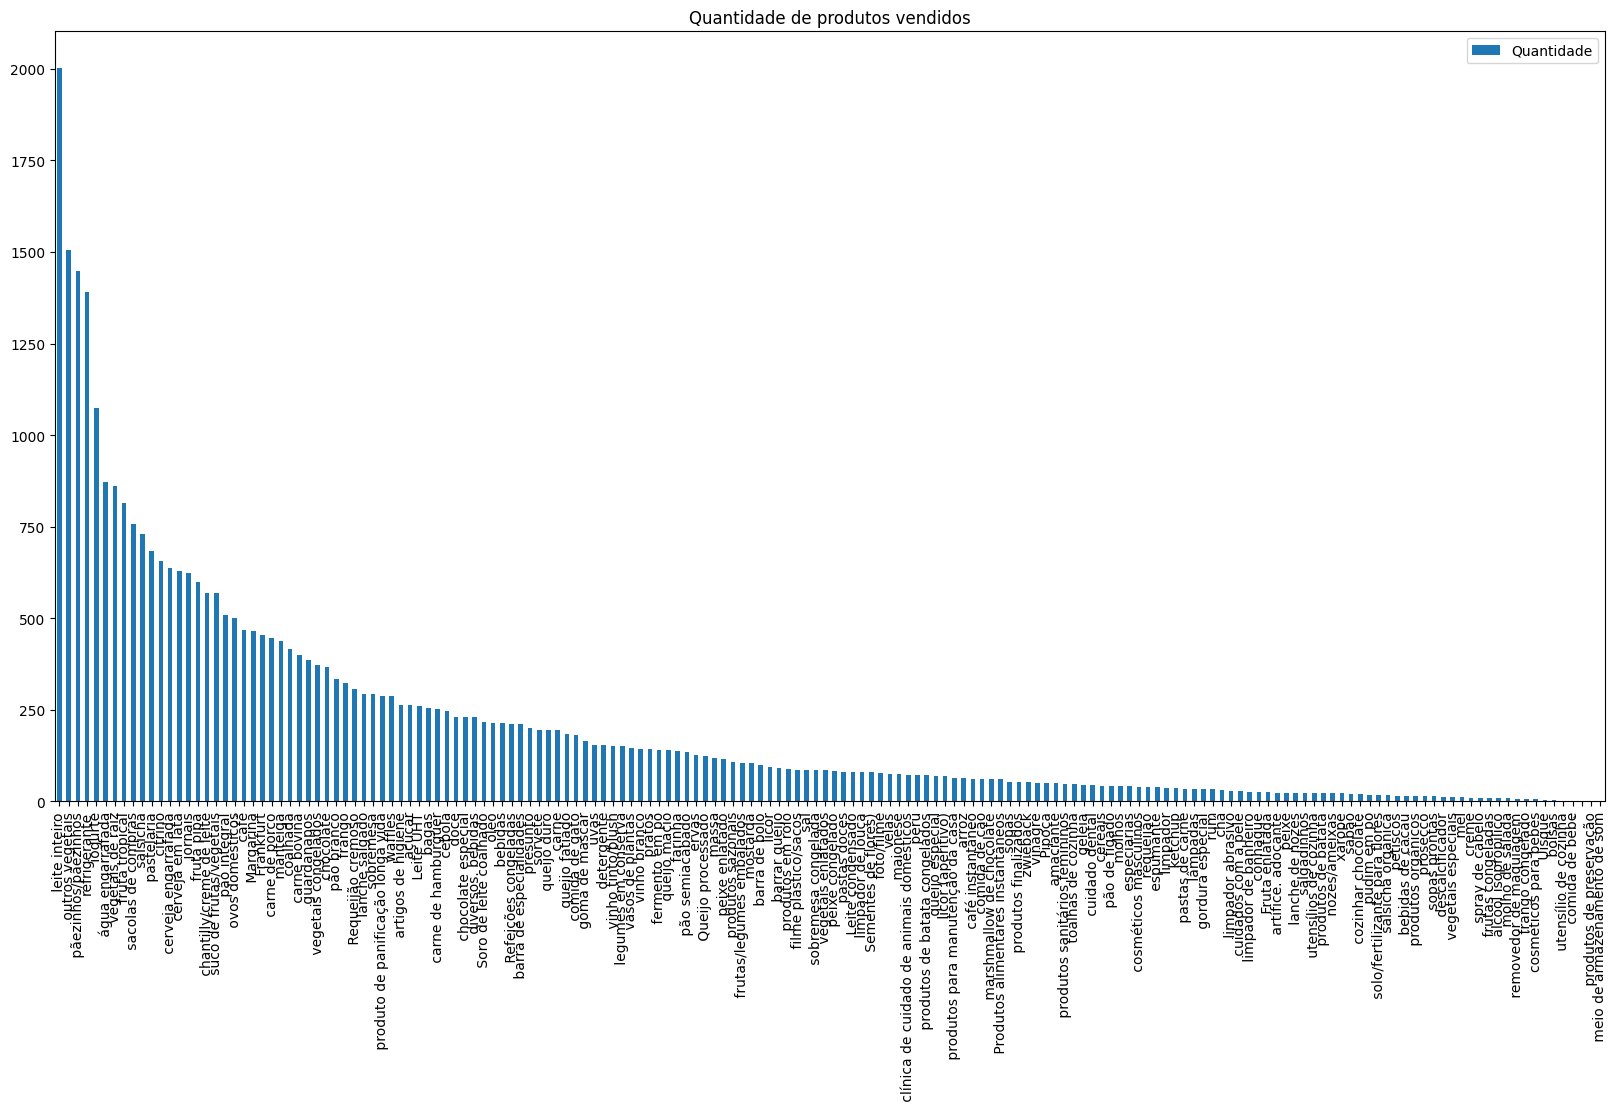

In [14]:
#Gerendo gráfico com todos os itens vendidos
compra_soma.sort_values(by='Quantidade',ascending=False).plot.bar(figsize=(20,10), title='Quantidade de produtos vendidos');

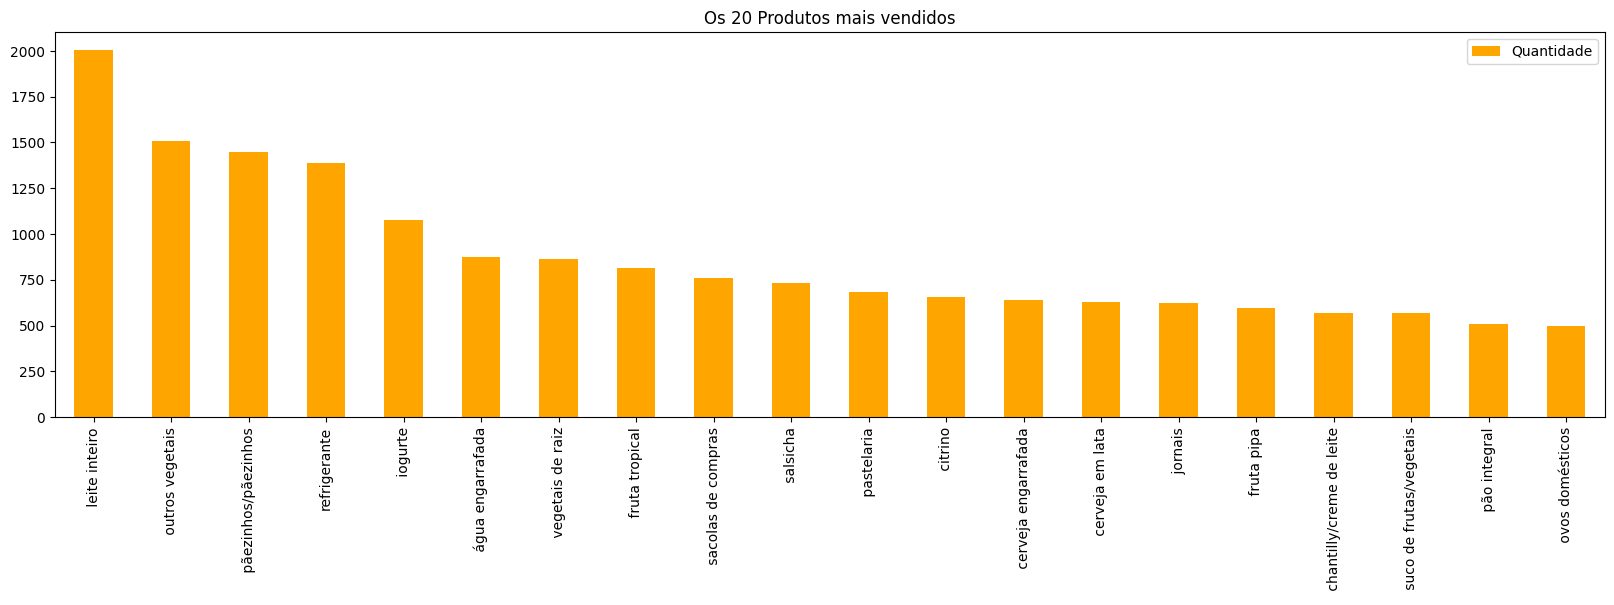

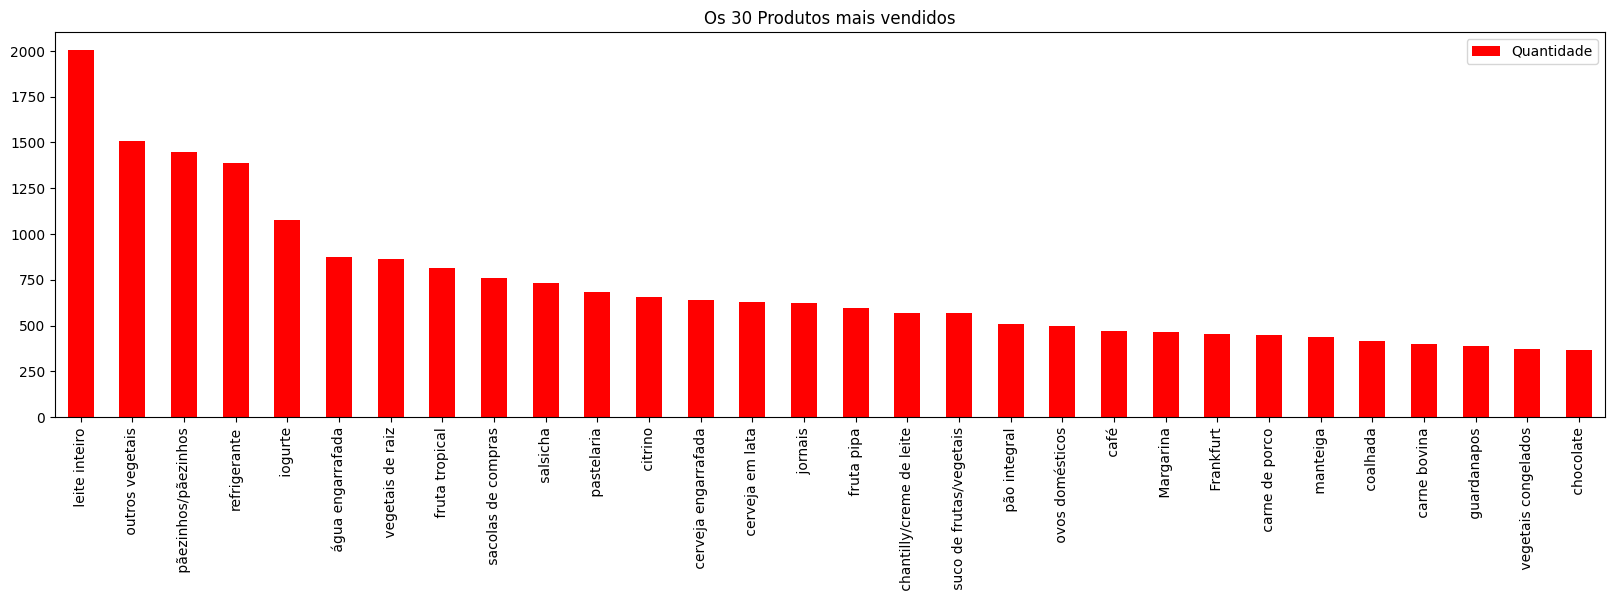

In [15]:
# Agora os 20 e 30 mais vendidos
compra_soma.sort_values(by='Quantidade',ascending=False).head(20).plot.bar(figsize=(20,5), color='orange', title='Os 20 Produtos mais vendidos');

compra_soma.sort_values(by='Quantidade',ascending=False).head(30).plot.bar(figsize=(20,5), color='red', title='Os 30 Produtos mais vendidos');

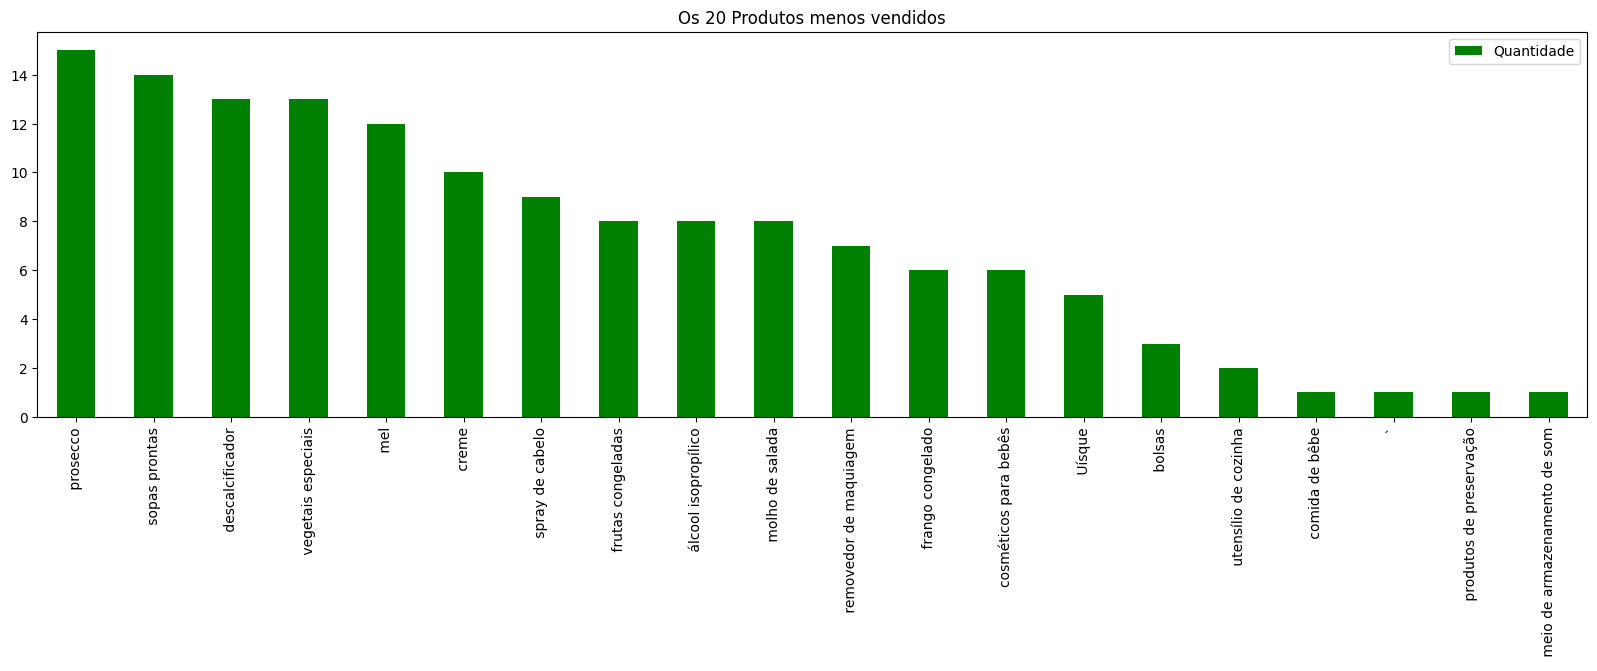

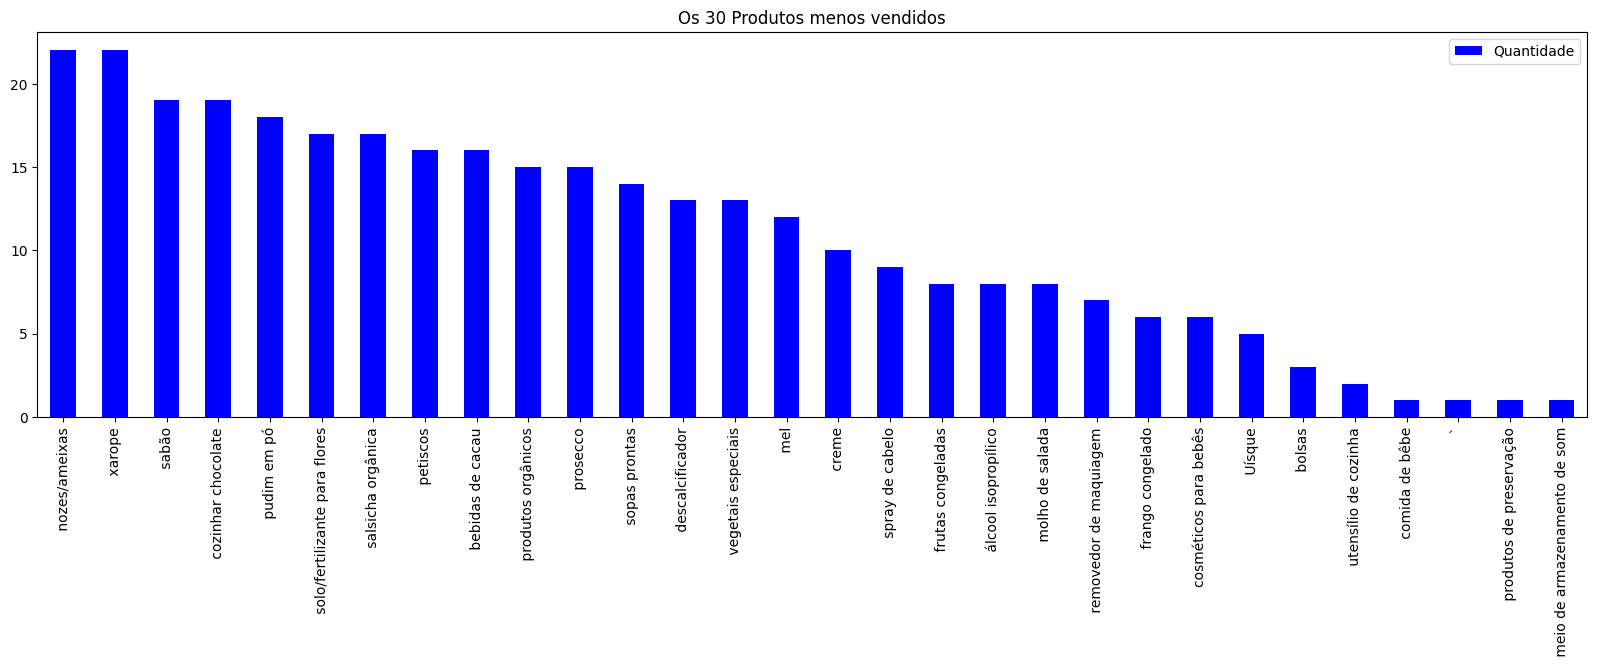

In [16]:
#Agora são os com menor venda
compra_soma.sort_values(by='Quantidade',ascending=False).tail(20).plot.bar(figsize=(20,5), color='green', title='Os 20 Produtos menos vendidos');

compra_soma.sort_values(by='Quantidade',ascending=False).tail(30).plot.bar(figsize=(20,5), color='blue', title='Os 30 Produtos menos vendidos');

# Aplicação do Algoritmo Apriori

O algoritmo *Apriori* é um método de aprendizado de máquina baseado em regras e trabalha com a ideia de itens mais frequentes, extraindo regras que relacionam esse itens. Esse algoritmo foi projeto para trabalhar em grandes bancos de dados. O Apriori é bastante eficar para analisar as cestas de mercado de compras de clientes (principalmente no setor de varejo), mas também está sendo usado na área da saúde para identificação de reações adversas de medicamentos.

Esse algoritmo utiliza a regra do SE..., ENTÃO, como por exemplo: "SE pão for comprado, ENTÃO café será comprado também". Além disso pode ser dada especificações para as regras por meios de certos parâmetros. O algoritmo Apriori utiliza algumas métricas para gerar as regras, que são:

*   Suporte: Trata da popularidade de um item, ou seja, quantas vezes esse item aparece em nossa base de dados. Quando temos uma base de dados pequena é normal que esse valor seja alta, mas a medida que o conjunto de dados e a variedade de itens aumenta, o valor do suporte tende a diminuir;
*   Confiança : Essa métrica indica a probabilidade de compra de um item Y dado que o item X foi comprado. O mesmo que ocorre com o suporte ocorre com essa métrica, quanto mais o mix de itens aumenta menor pode ser o valor dessa métrica. Aqui teremos o valor entre 0 e 1;
*   LIFT : probabilidade de o item Y ser comprado quando o item X é comprado, também controlando a popularidade do item Y. O valor dessa métrica é acima de 0.

Vamos então aplicar o algortimo Apriori para a nossa base de dados, mas antes vamos criar uma lista com os dados.

In [17]:
transacoes=[]
for i in range(0,9002):
    transacoes.append([str(compra.values[i,j]) for j in range(0,32)])

# Aplicando o algoritmo Apriori

Para o suporte (*min_support*) usaremos o valor de 0.003. Esse valor foi escolhido, pois queremos os itens que são comprados pelo menos 4 vezes ao dia durante uma semana e dividimos pelo número total (9002).

A confiança (*min_confidence*) usaremos o valor de 70% (ou seja, a probabilidade de se comprar Y dado que X foi comprado deve ser de 70% para cima).

O Lift mínimo (*min_lift*) será igual a 2, ou seja, dado que se compra X a chance de se comprar Y deve ser maior igual tantas vezes a que foi definida nesse parâmetro. Ou seja, que pelo menos ao comprar X a chance de compra Y deve ser 2 vezes.

E, por fim, no min_lenght teremos a quantidade mínina de itens que ele vai gerar por regras, ou seja, deve ter pelo menos um item antes do SE e outro após o ENTÃO.

In [44]:
regras=apriori(transacoes, min_support=0.003,min_confidence=0.7,min_lift=2, min_lenght=2)

In [45]:
#Visuallizando os resultados
resultado=list(regras)
resultado

[RelationRecord(items=frozenset({' ovos domésticos', ' leite inteiro', ' Requeijão cremoso'}), support=0.0033325927571650742, ordered_statistics=[OrderedStatistic(items_base=frozenset({' ovos domésticos', ' Requeijão cremoso'}), items_add=frozenset({' leite inteiro'}), confidence=0.7142857142857142, lift=3.2117882117882113)]),
 RelationRecord(items=frozenset({' ovos domésticos', ' leite inteiro', ' açúcar'}), support=0.0034436791824039104, ordered_statistics=[OrderedStatistic(items_base=frozenset({' ovos domésticos', ' açúcar'}), items_add=frozenset({' leite inteiro'}), confidence=0.7045454545454546, lift=3.1679910998092815)]),
 RelationRecord(items=frozenset({' ovos domésticos', ' leite inteiro', ' coalhada'}), support=0.004443457009553432, ordered_statistics=[OrderedStatistic(items_base=frozenset({' ovos domésticos', ' coalhada'}), items_add=frozenset({' leite inteiro'}), confidence=0.7142857142857142, lift=3.2117882117882113)]),
 RelationRecord(items=frozenset({' ovos domésticos', '

In [46]:
resultado2=[list(x) for x in resultado]
resultado2

[[frozenset({' Requeijão cremoso', ' leite inteiro', ' ovos domésticos'}),
  0.0033325927571650742,
  [OrderedStatistic(items_base=frozenset({' ovos domésticos', ' Requeijão cremoso'}), items_add=frozenset({' leite inteiro'}), confidence=0.7142857142857142, lift=3.2117882117882113)]],
 [frozenset({' açúcar', ' leite inteiro', ' ovos domésticos'}),
  0.0034436791824039104,
  [OrderedStatistic(items_base=frozenset({' ovos domésticos', ' açúcar'}), items_add=frozenset({' leite inteiro'}), confidence=0.7045454545454546, lift=3.1679910998092815)]],
 [frozenset({' coalhada', ' leite inteiro', ' ovos domésticos'}),
  0.004443457009553432,
  [OrderedStatistic(items_base=frozenset({' ovos domésticos', ' coalhada'}), items_add=frozenset({' leite inteiro'}), confidence=0.7142857142857142, lift=3.2117882117882113)]],
 [frozenset({' Requeijão cremoso',
             ' leite inteiro',
             ' ovos domésticos',
             'nan'}),
  0.0032215063319262385,
  [OrderedStatistic(items_base=frozen

In [47]:
#Quantitativo de associações identificadas
len(resultado2)

20

In [30]:
#Visualizando as 7 principais regras de associação gerada
reg_associadas=[]
for j in range(0,5):
    reg_associadas.append([list(x) for x in resultado2[j][2]])

In [31]:
reg_associadas

[[[frozenset({' Requeijão cremoso', ' ovos domésticos'}),
   frozenset({' leite inteiro'}),
   0.7142857142857142,
   3.2117882117882113]],
 [[frozenset({' açúcar', ' ovos domésticos'}),
   frozenset({' leite inteiro'}),
   0.7045454545454546,
   3.1679910998092815]],
 [[frozenset({' coalhada', ' ovos domésticos'}),
   frozenset({' leite inteiro'}),
   0.7142857142857142,
   3.2117882117882113]],
 [[frozenset({' Requeijão cremoso', ' ovos domésticos', 'nan'}),
   frozenset({' leite inteiro'}),
   0.7073170731707317,
   3.1804536926488143]],
 [[frozenset({' chantilly/creme de leite', ' fruta tropical', ' iogurte'}),
   frozenset({' leite inteiro'}),
   0.7307692307692307,
   3.285906401291016]]]